In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# Read and prepare the data
dataset = pd.DataFrame([
    [2104,3,399900], [1600,3,329900], [2400,3,369000], [1416,2,232000],
    [3000,4,539900], [1985,4,299900], [1534,3,314900], [1427,3,198999],
    [1380,3,212000], [1494,3,242500], [1940,4,239999], [2000,3,347000],
    [1890,3,329999], [4478,5,699900], [1268,3,259900], [2300,4,449900],
    [1320,2,299900], [1236,3,199900], [2609,4,499998], [3031,4,599000],
    [1767,3,252900], [1888,2,255000], [1604,3,242900], [1962,4,259900],
    [3890,3,573900], [1100,3,249900], [1458,3,464500], [2526,3,469000],
    [2200,3,475000], [2637,3,299900], [1839,2,349900], [1000,1,169900],
    [2040,4,314900], [3137,3,579900], [1811,4,285900], [1437,3,249900],
    [1239,3,229900], [2132,4,345000], [4215,4,549000], [2162,4,287000],
    [1664,2,368500], [2238,3,329900], [2567,4,314000], [1200,3,299000],
    [852,2,179900], [1852,4,299900], [1203,3,239500]
], columns=['SquareFeet', 'Bedrooms', 'Price'])


# Prepare input and output data
inputx = dataset.iloc[:, 0:2].values
outputy = dataset.iloc[:, 2].values


# Split the data
input_train, input_test, output_train, output_test = train_test_split(
    inputx, outputy, test_size=1/4, random_state=0
)

In [3]:
# Train the model
model = LinearRegression()
model.fit(input_train, output_train)

LinearRegression()

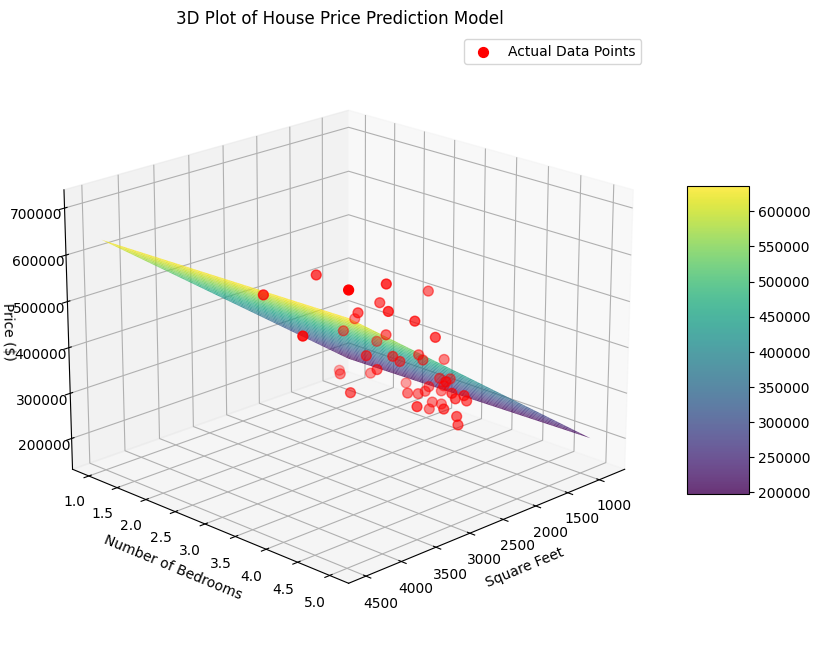

Model Coefficients:
Square Feet coefficient: 122.27
Bedrooms coefficient: 2799.79
Intercept: 82412.70


In [4]:
# Create meshgrid for 3D surface plot
square_feet_range = np.linspace(min(dataset['SquareFeet']), max(dataset['SquareFeet']), 30)
bedrooms_range = np.linspace(min(dataset['Bedrooms']), max(dataset['Bedrooms']), 30)
X, Y = np.meshgrid(square_feet_range, bedrooms_range)
Z = model.predict(np.array([X.ravel(), Y.ravel()]).T).reshape(X.shape)


# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)


# Plot the actual data points
ax.scatter(dataset['SquareFeet'], dataset['Bedrooms'], dataset['Price'],
          color='red', s=50, label='Actual Data Points')


# Customize the plot
ax.set_xlabel('Square Feet')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('Price ($)')
ax.set_title('3D Plot of House Price Prediction Model')


# Add color bar
fig.colorbar(surf, shrink=0.5, aspect=5)


# Add legend
ax.legend()


# Adjust the viewing angle
ax.view_init(elev=20, azim=45)


plt.show()


# Print model coefficients
print(f"Model Coefficients:")
print(f"Square Feet coefficient: {model.coef_[0]:.2f}")
print(f"Bedrooms coefficient: {model.coef_[1]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")